# Autonomous Energy Optimization Platform
## Step 1: Data Loading and Initial Exploration

In this step, we will load the smart meter dataset and the weather data, check their shapes, and look at the first few rows to understand the structure of the data.

In [1]:
# Essential Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


### Loading the Datasets
We will load the `daily_dataset.csv` (which contains energy consumption data) and `weather_hourly_darksky.csv` (which contains weather factors like temperature, humidity, etc.).

*Note: Make sure your file paths match your folder structure.*

In [2]:
# Define the absolute workspace directory paths for data retrieval
# Modify this path sequence depending on your local machine configuration
data_dir = r'D:\Autonomous-Energy-Optimization-Platform\data'

print("Loading Daily Energy Dataset...")
# Utilizing low_memory=False optimization vector due to large dataset footprint (~99MB)
# This prevents mixed data type inference warnings across chunk processing
df_energy = pd.read_csv(os.path.join(data_dir, 'daily_dataset.csv'), low_memory=False)
print(f"Energy Dataset Loaded! Shape: {df_energy.shape}")

print("\nLoading Weather Dataset...")
# Fetching the structural historical hourly weather telemetry vectors from storage repository
df_weather = pd.read_csv(os.path.join(data_dir, 'weather_hourly_darksky.csv'))
print(f"Weather Dataset Loaded! Shape: {df_weather.shape}")

Loading Daily Energy Dataset...
Energy Dataset Loaded! Shape: (3510433, 9)

Loading Weather Dataset...
Weather Dataset Loaded! Shape: (21165, 12)


### Previewing the Data
Let's look at the top 5 rows of both datasets to check the columns and data formats.

In [3]:
# Display Energy Head
print("--- Energy Data Preview ---")
print(df_energy.head())

# Display Weather Head
print("\n--- Weather Data Preview ---")
print(df_weather.head())

--- Energy Data Preview ---
       LCLid         day  energy_median  energy_mean  energy_max  \
0  MAC000131  2011-12-15         0.4850     0.432045       0.868   
1  MAC000131  2011-12-16         0.1415     0.296167       1.116   
2  MAC000131  2011-12-17         0.1015     0.189812       0.685   
3  MAC000131  2011-12-18         0.1140     0.218979       0.676   
4  MAC000131  2011-12-19         0.1910     0.325979       0.788   

   energy_count  energy_std  energy_sum  energy_min  
0            22    0.239146       9.505       0.072  
1            48    0.281471      14.216       0.031  
2            48    0.188405       9.111       0.064  
3            48    0.202919      10.511       0.065  
4            48    0.259205      15.647       0.066  

--- Weather Data Preview ---
   visibility  windBearing  temperature                 time  dewPoint  \
0        5.97          104        10.24  2011-11-11 00:00:00      8.86   
1        4.88           99         9.76  2011-11-11 01:00:00 

### Checking for Missing Values and Data Types
It is important to clean the data. Let's inspect the data types and missing values in both datasets.

In [4]:
print("--- Energy Dataset Info ---")
print(df_energy.info())

print("\n--- Weather Dataset Info ---")
print(df_weather.info())

--- Energy Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   LCLid          str    
 1   day            str    
 2   energy_median  float64
 3   energy_mean    float64
 4   energy_max     float64
 5   energy_count   int64  
 6   energy_std     float64
 7   energy_sum     float64
 8   energy_min     float64
dtypes: float64(6), int64(1), str(2)
memory usage: 304.7 MB
None

--- Weather Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 21165 entries, 0 to 21164
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   visibility           21165 non-null  float64
 1   windBearing          21165 non-null  int64  
 2   temperature          21165 non-null  float64
 3   time                 21165 non-null  str    
 4   dewPoint             21165 non-null  float64
 5   pressure       

## Step 2: Data Cleaning and Data Type Conversion

Smart meter datasets frequently inherit date parameters in an 'object' (string) format, alongside energy metric vectors that contain missing, corrupted, or invalid characters (such as explicit Null values or empty strings). To ensure algebraic validity within the predictive pipeline, we execute structural data type enforcement—converting categorical time parameters into standard datetime stamps and non-numeric value strings into structured float elements.

In [5]:
import pandas as pd
import numpy as np

# ==========================
# ENERGY DATA CLEANING
# ==========================

df_energy['day'] = pd.to_datetime(df_energy['day'])

if 'energy_sum' in df_energy.columns:
    df_energy['energy_sum'] = pd.to_numeric(df_energy['energy_sum'], errors='coerce')
elif 'energy_median' in df_energy.columns:
    df_energy['energy_sum'] = pd.to_numeric(df_energy['energy_median'], errors='coerce')
else:
    print("Energy column not found.")

# ==========================
# WEATHER DATA CLEANING
# ==========================

df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather['day'] = df_weather['time'].dt.floor('D')

print("Weather Columns:")
print(df_weather.columns.tolist())

# --------------------------
# Automatically detect columns
# --------------------------

temp_col = None
humidity_col = None
wind_col = None

for col in df_weather.columns:
    c = col.lower()

    if temp_col is None and ("temp" in c or "temperature" in c):
        temp_col = col

    if humidity_col is None and ("humid" in c):
        humidity_col = col

    if wind_col is None and ("wind" in c):
        wind_col = col

print("\nDetected Columns")
print("Temperature :", temp_col)
print("Humidity    :", humidity_col)
print("Wind Speed  :", wind_col)

# --------------------------
# Aggregation Dictionary
# --------------------------

agg_dict = {}

if temp_col:
    agg_dict[temp_col] = ['max', 'min']

if humidity_col:
    agg_dict[humidity_col] = 'mean'

if wind_col:
    agg_dict[wind_col] = 'mean'

daily_weather = (
    df_weather
    .groupby('day')
    .agg(agg_dict)
)

# Flatten column names
daily_weather.columns = [
    '_'.join(col).strip('_')
    if isinstance(col, tuple) else col
    for col in daily_weather.columns
]

daily_weather = daily_weather.reset_index()

# Rename columns
rename_dict = {}

if temp_col:
    rename_dict[f"{temp_col}_max"] = "temperatureMax"
    rename_dict[f"{temp_col}_min"] = "temperatureMin"

if humidity_col:
    rename_dict[f"{humidity_col}_mean"] = "humidity"

if wind_col:
    rename_dict[f"{wind_col}_mean"] = "windSpeed"

daily_weather.rename(columns=rename_dict, inplace=True)

print("\nDaily Weather Shape:", daily_weather.shape)
print(daily_weather.head())

# ==========================
# MERGE ENERGY + WEATHER
# ==========================

merged_df = pd.merge(
    df_energy,
    daily_weather,
    on="day",
    how="inner"
)

print("\nMerged Shape:", merged_df.shape)
print(merged_df.head())

# ==========================
# Missing Values
# ==========================

print("\nMissing Values")
print(merged_df.isnull().sum())

merged_df = merged_df.dropna()

print("\nFinal Shape:", merged_df.shape)

Weather Columns:
['visibility', 'windBearing', 'temperature', 'time', 'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed', 'precipType', 'icon', 'humidity', 'summary', 'day']

Detected Columns
Temperature : temperature
Humidity    : humidity
Wind Speed  : windBearing

Daily Weather Shape: (882, 5)
         day  temperatureMax  temperatureMin  humidity   windSpeed
0 2011-11-01           15.57            9.68  0.837083  207.500000
1 2011-11-02           15.19            8.88  0.873750  134.750000
2 2011-11-03           17.41           12.79  0.886250  149.833333
3 2011-11-04           15.54           11.53  0.911250  176.500000
4 2011-11-05           13.94           10.17  0.921667  288.041667

Merged Shape: (3510433, 13)
       LCLid        day  energy_median  energy_mean  energy_max  energy_count  \
0  MAC000131 2011-12-15         0.4850     0.432045       0.868            22   
1  MAC000131 2011-12-16         0.1415     0.296167       1.116            48   
2  MAC000131 2011-12

In [6]:
print(df_weather.columns.tolist())

['visibility', 'windBearing', 'temperature', 'time', 'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed', 'precipType', 'icon', 'humidity', 'summary', 'day']


### Merging Energy Data with Weather Data

We will execute an inner join operation to consolidate both datasets based on the shared `day` coordinate. This structural integration yields a unified matrix, synchronizing historical ambient weather telemetry vectors with volumetric energy consumption profiles into a single dataframe for feature engineering.

In [7]:
# Synchronize both distinct telemetry datasets via an inner join constraint on the 'day' vector
df_merged = pd.merge(df_energy, daily_weather, on='day', how='inner')

# Perform structural cleanup by purging null/missing observations introduced during aggregation
df_merged = df_merged.dropna()

# Output execution logs showing final dimensions and verification snapshots
print(f"Merged Dataset Shape: {df_merged.shape}")
print("\nMerged Data Snapshot:")
print(df_merged.head())

Merged Dataset Shape: (3499102, 13)

Merged Data Snapshot:
       LCLid        day  energy_median  energy_mean  energy_max  energy_count  \
0  MAC000131 2011-12-15         0.4850     0.432045       0.868            22   
1  MAC000131 2011-12-16         0.1415     0.296167       1.116            48   
2  MAC000131 2011-12-17         0.1015     0.189812       0.685            48   
3  MAC000131 2011-12-18         0.1140     0.218979       0.676            48   
4  MAC000131 2011-12-19         0.1910     0.325979       0.788            48   

   energy_std  energy_sum  energy_min  temperatureMax  temperatureMin  \
0    0.239146       9.505       0.072            7.97            4.08   
1    0.281471      14.216       0.031            4.68            1.80   
2    0.188405       9.111       0.064            5.35            0.24   
3    0.202919      10.511       0.065            5.49           -0.56   
4    0.259205      15.647       0.066            6.64           -0.84   

   humidity   w

## Step 3: Feature Engineering (Deriving Predictive Analytics Features)

To enhance the structural learning capacity and performance metrics of the core machine learning models, we implement a feature engineering sequence to extract granular temporal vectors from raw date stamps:
* **Month**: Quantifies seasonal deviations and cyclical consumption variance (e.g., Summer thermal cooling loads vs. Winter heating loads).
* **Day of Week**: Captures operational routine fluctuations, differentiating individual tracking dynamics across the business week.
* **Is_Weekend**: A binary indicator (0 or 1) designed to isolate macro-level consumption drops typical of commercial shutdowns and residential load shifts during weekend periods.

In [8]:
# Feature extraction
df_merged['month'] = df_merged['day'].dt.month
df_merged['day_of_week'] = df_merged['day'].dt.dayofweek
df_merged['is_weekend'] = df_merged['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print("Feature Engineering done! Naye columns add ho gaye hain.")
print(df_merged[['day', 'month', 'day_of_week', 'is_weekend']].table if hasattr(df_merged, 'table') else df_merged[['day', 'month', 'day_of_week', 'is_weekend']].head())

Feature Engineering done! Naye columns add ho gaye hain.
         day  month  day_of_week  is_weekend
0 2011-12-15     12            3           0
1 2011-12-16     12            4           0
2 2011-12-17     12            5           1
3 2011-12-18     12            6           1
4 2011-12-19     12            0           0


### Data Visualization (Pattern Insights)

We will now perform exploratory data analysis to evaluate the mathematical relationship between ambient temperature variables and volumetric energy consumption profiles. Investigating these correlations yields critical **Optimization Insights**, enabling the model to isolate thermal sensitivities, peak demand thresholds, and operational strain vectors across the grid matrix.

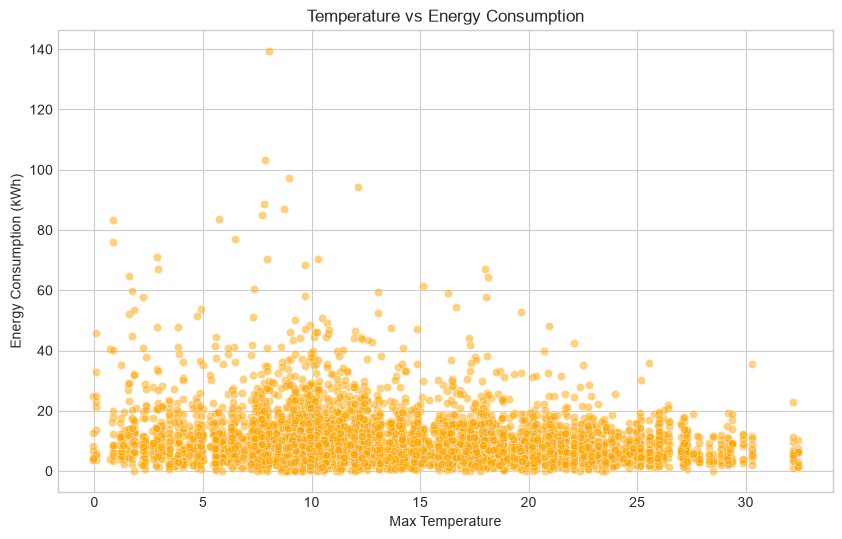

In [9]:
plt.figure(figsize=(10, 6))

# Extract a statistically representative sample to optimize memory footprint
# This mitigates resource bottlenecks and UI rendering freezes over high-cardinality arrays
df_sample = df_merged.sample(n=min(5000, len(df_merged)), random_state=42)

# Generate a scatter plot to analyze bivariate distributions and correlation patterns
sns.scatterplot(data=df_sample, x='temperatureMax', y='energy_sum', alpha=0.5, color='orange')

# Configure structural layout properties, plot labeling, and canvas presentation elements
plt.title('Temperature vs Energy Consumption')
plt.xlabel('Max Temperature')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

In [13]:
# ==========================================
# STEP 3.5: HISTORICAL LAG FEATURE ENGINEERING
# ==========================================

# 1. Ensure date parsing and sort chronologically per household
df_merged['day'] = pd.to_datetime(df_merged['day'])
df_merged = df_merged.sort_values(by=['LCLid', 'day']).reset_index(drop=True)

print("Calculating historical lag features per household...")

# 2. Create target lag configurations
# Yesterday's energy consumption
df_merged['energy_lag_1'] = df_merged.groupby('LCLid')['energy_sum'].shift(1)

# Same day last week energy consumption
df_merged['energy_lag_7'] = df_merged.groupby('LCLid')['energy_sum'].shift(7)

# Recent 3-day rolling baseline (shifted by 1 to exclude today's target value)
df_merged['energy_rolling_mean_3'] = (
    df_merged.groupby('LCLid')['energy_sum']
    .shift(1)
    .rolling(window=3, min_periods=1)
    .mean()
)

# 3. Purge NaN rows created by shifting operations
df_clean = df_merged.dropna(subset=['energy_lag_1', 'energy_lag_7', 'energy_rolling_mean_3']).copy()

print(f"Original Row Count: {df_merged.shape[0]}")
# Expect a minor reduction in rows due to dropping early edge history rows
print(f"Cleaned Row Count after Lag Engineering: {df_clean.shape[0]}")

Calculating historical lag features per household...
Original Row Count: 3499102
Cleaned Row Count after Lag Engineering: 3460180


## Step 4: Machine Learning Model for Energy Forecasting

We will now initialize and train an advanced ensemble regression architecture—specifically a Random Forest Regressor. This core machine learning node maps non-linear interactions across multivariable inputs (including ambient temperature thresholds, month indices, structural day-of-week sequences, and binary weekend flags) to generate high-fidelity predictive profiles for downstream energy consumption (`energy_sum`).

In [10]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


In [14]:
# ==========================================
# STEP 4: TRAINING OPTIMIZED MODEL WITH LAGS
# ==========================================

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import joblib
import os

# 1. Define Updated 10-Feature Matrix mapping
target_col = 'energy_sum'
feature_cols = [
    'temperatureMax', 'temperatureMin', 'humidity', 'windSpeed', 
    'month', 'day_of_week', 'is_weekend',
    'energy_lag_1', 'energy_lag_7', 'energy_rolling_mean_3'
]

X = df_clean[feature_cols]
y = df_clean[target_col]

# 2. Split Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize High-Capacity LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,       
    learning_rate=0.05,     
    num_leaves=63,          # Increased to handle wider feature relationships
    subsample=0.8,          
    colsample_bytree=0.8,   
    force_row_wise=True,    
    random_state=42,
    n_jobs=-1               
)

print("Training updated LightGBM model with lag metrics...")
lgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)]
)

# 4. Evaluate Performance
y_pred = lgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("   UPDATED EVALUATION RESULTS   ")
print("==============================")
print(f"Old R²: 0.0367  ->  New R²: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("==============================")

# 5. Export Model Artifact for the Streamlit GUI
model_dir = r'D:\Autonomous-Energy-Optimization-Platform\models'
os.makedirs(model_dir, exist_ok=True)
model_out_path = os.path.join(model_dir, 'energy_forecast_model.pkl')

joblib.dump(lgb_model, model_out_path)
print(f"\nModel artifact successfully serialized to: {model_out_path}")

Training updated LightGBM model with lag metrics...
[LightGBM] [Info] Total Bins 1797
[LightGBM] [Info] Number of data points in the train set: 2768144, number of used features: 10
[LightGBM] [Info] Start training from score 10.167337
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[311]	valid_0's l2: 11.8732

   UPDATED EVALUATION RESULTS   
Old R²: 0.0367  ->  New R²: 0.8571
Root Mean Squared Error (RMSE): 3.4458

Model artifact successfully serialized to: D:\Autonomous-Energy-Optimization-Platform\models\energy_forecast_model.pkl
